In [1]:
# Cell 1: Imports & Parameter
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_final\log_ppo_S1_final\ppo_log_state1_cpcv_20251217_071408\E2")
paths = [f"Path_{i:02d}" for i in range(1, 6)]

def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


In [2]:
df_btc = load_and_info(run_dir / "Path_01/rewards.parquet")
display(df_btc.head(), df_btc.tail())


--- rewards.parquet ---
Shape: (1505, 15)
Columns: 15


,round,t,nav_t,nav_t-1,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
0,1,2015-01-05 00:00:00+00:00,1.000001e+06,1.000000e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1,2,2015-01-06 00:00:00+00:00,1.000002e+06,1.000001e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
2,3,2015-01-07 00:00:00+00:00,1.000003e+06,1.000002e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
3,4,2015-01-08 00:00:00+00:00,1.000003e+06,1.000003e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
4,5,2015-01-09 00:00:00+00:00,1.000004e+06,1.000003e+06,5.555554e-07,0.0,0.0,5.555554e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1


,round,t,nav_t,nav_t-1,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
1500,1506,2020-12-24 00:00:00+00:00,1.973936e+06,1.941811e+06,0.016409,0.0,0.0,0.016409,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1501,1507,2020-12-28 00:00:00+00:00,2.147729e+06,1.973936e+06,0.084381,0.0,0.0,0.084381,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1502,1508,2020-12-29 00:00:00+00:00,2.160035e+06,2.147729e+06,0.005714,0.0,0.0,0.005714,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1503,1509,2020-12-30 00:00:00+00:00,2.210997e+06,2.160035e+06,0.023319,0.0,0.0,0.023319,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1504,1510,2020-12-31 00:00:00+00:00,2.200978e+06,2.210997e+06,-0.004542,0.0,0.0,-0.004542,log,ex_ante,0.05,1.0,1.0,rolling,0.1


In [3]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


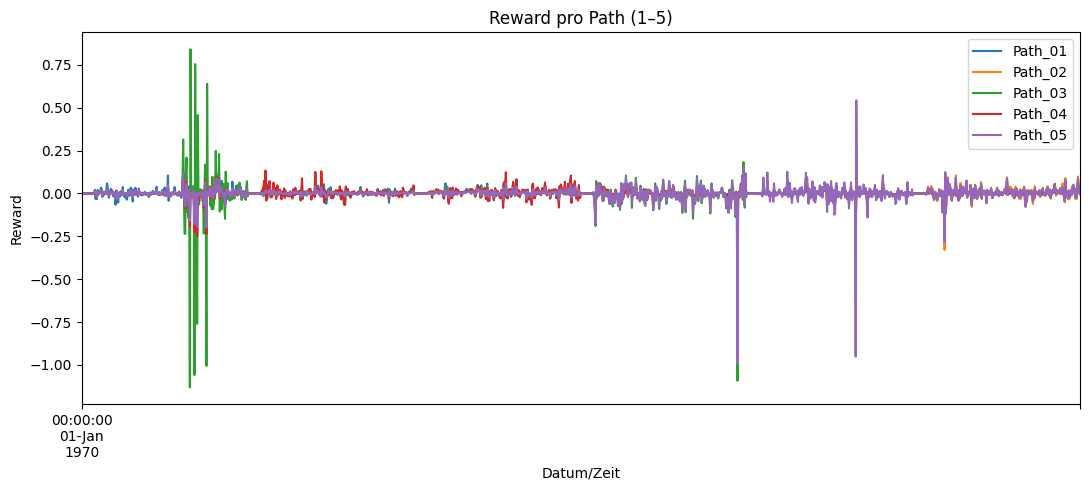

In [4]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("Reward pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()


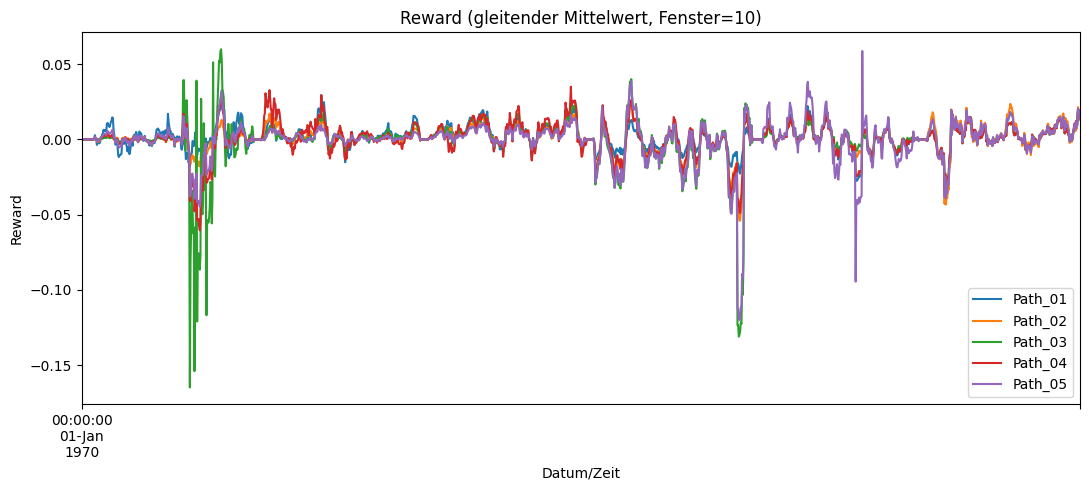

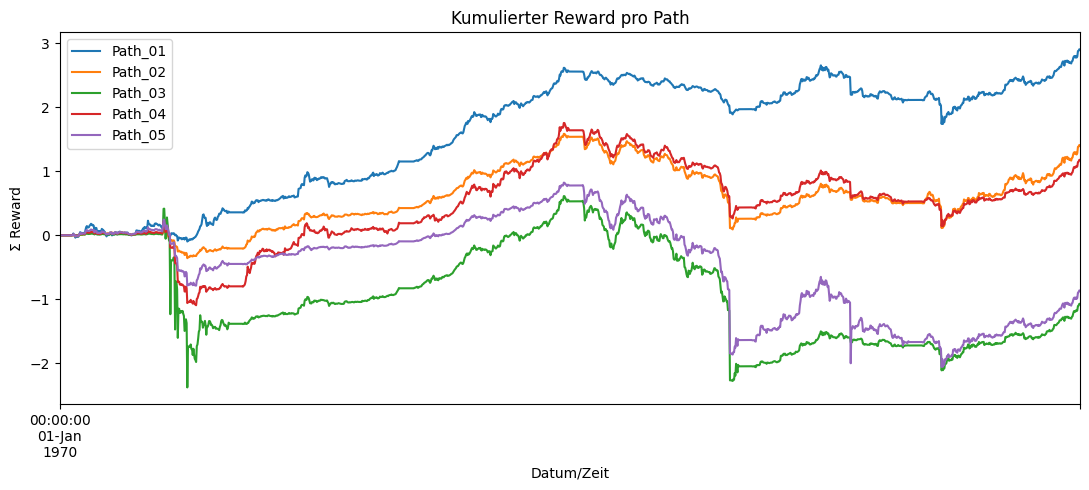

In [5]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [6]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


Path_01
Path_02
Path_03
Path_04
Path_05


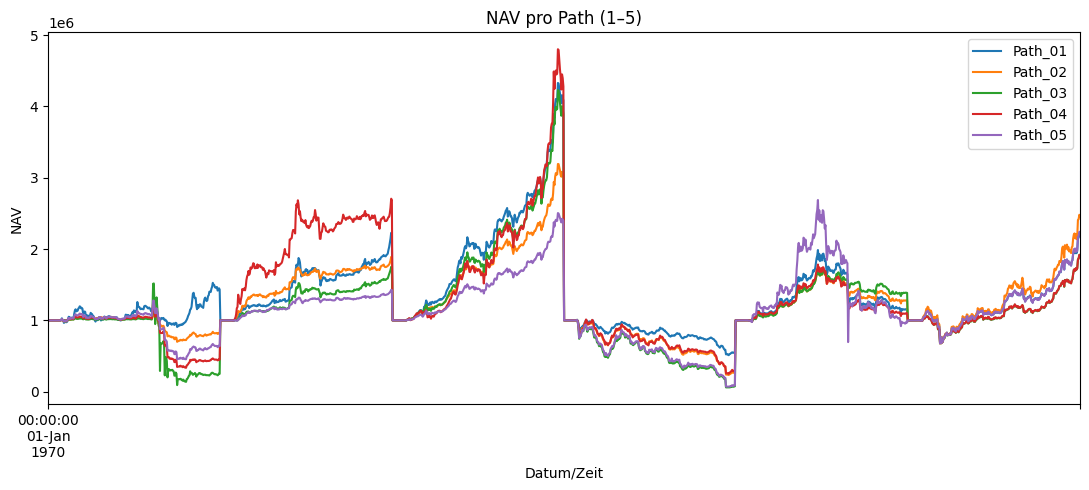

In [7]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

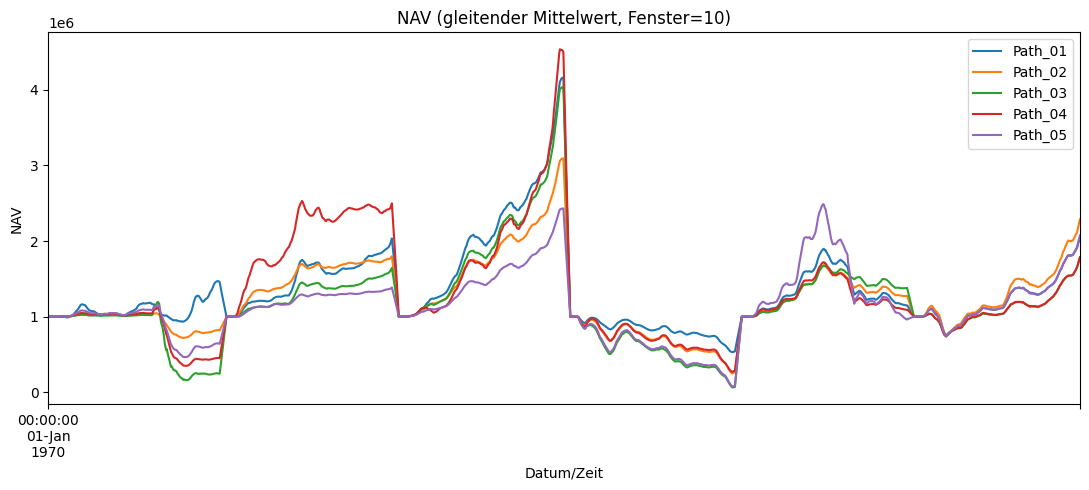

In [8]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()
